# Data Loading and Cleaning

Charge, inspecte, nettoie et sauvegarde la version production-ready du dataset
de cantine BNP Paribas RIE.

**Convention de nommage** (cohérente avec le code existant `src/`):
- `office_presence` → `office_present` (feature du modèle principal)
- `cantine_presence` → `employees_count` (cible = repas servi)

**Sortie**: `data/processed/real_clean.csv`

---
## Section 1 — Raw Load and Inspection

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path().resolve().parent
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROC_DIR = REPO_ROOT / 'data' / 'processed'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(
    RAW_DIR / 'real.csv',
    sep=';',
    encoding='cp1252',
    parse_dates=['Date'],
    dayfirst=True,
)
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")
print(f"Columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
print()
print(df_raw.head(5).to_string())
print()
print("--- dtypes ---")
print(df_raw.dtypes)
print()
print("--- Nulls ---")
print(df_raw.isnull().sum())
print()
print("--- Numeric stats ---")
print(df_raw.describe().to_string())

Shape: (666, 14)
Date range: 2022-01-02 to 2024-12-31
Columns (14): ['Date', 'office_presence', 'cantine_presence', 'entrées', 'plat pricipal_1', 'plat principal_2', 'temperature', 'temperature ressentie', 'precipitation (mm)', 'type precipitation', 'vitesse soulevement du vent (km/h)', 'vitesse du vent(km/h)', 'couverture nuageuse (%)', 'conditions']

        Date  office_presence  cantine_presence                entrées           plat pricipal_1  plat principal_2  temperature  temperature ressentie  precipitation (mm) type precipitation  vitesse soulevement du vent (km/h)  vitesse du vent(km/h)  couverture nuageuse (%)              conditions
0 2022-01-02              429                 0      Soupe pois cassés  Blanc de poulet au curry    Pomme fondante         12.9                   12.9                 0.0                  0                                11.9                   11.2                     35.2        Partially cloudy
1 2022-01-03              420                 0  

In [2]:
# -- Value counts for text columns ------------------------------------------------
for col in ['entrées', 'plat pricipal_1', 'plat principal_2', 'type precipitation', 'conditions']:
    print(f"\n--- {col} (top 10) ---")
    print(df_raw[col].value_counts().head(10).to_string())


--- entrées (top 10) ---
entrées
Salade ou Soupe ou Salé      318
Salade ou Soupe               59
Salade                        42
Salade ou Soupe ou Bourak     34
Salé                          31
Salés                         25
Salade + salé                 23
Salade                        15
Salade ou Soupe ou salés      11
Salade + Soupe                 9

--- plat pricipal_1 (top 10) ---
plat pricipal_1
Rechta au poulet                32
Couscous au poulet              22
Tlitli au poulet                21
Sandwich                        18
Gratin de poulet                11
Kbab au poulet                  10
Lasagne viande                  10
Vol au vent sauce financière     9
Spaghetti bolognaise             8
Sandwich + Frite                 6

--- plat principal_2 (top 10) ---
plat principal_2
Menu Chef + Sandwich + Pizza                          26
Menu Chef                                             16
Grillade / Fritte / salade / Oeuf au plat/ Fromage    15
Grillade / Fr

---
## Section 2 — Date and Working Week

**Semaine de travail algérienne : Dimanche → Jeudi.**
Vendredi (4) et Samedi (5) sont le weekend.
Vérifie que DOW 6 (dimanche) est bien un jour de travail dans les données.

In [3]:
df_raw['dow'] = df_raw['Date'].dt.dayofweek

print("Distribution par jour de semaine (0=Lun .. 6=Dim):")
dow_counts = df_raw['dow'].value_counts().sort_index()
for d in range(7):
    label = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'][d]
    count = dow_counts.get(d, 0)
    flag = '  <-- weekend' if d in [4, 5] else '  <-- travail'
    print(f"  DOW {d} ({label}): {count:4d}{flag}")

# Algerian working week: Sun(6), Mon(0), Tue(1), Wed(2), Thu(3)
work_dows = [0, 1, 2, 3, 6]
weekend_dows = [4, 5]
n_work = sum(dow_counts.get(d, 0) for d in work_dows)
n_weekend = sum(dow_counts.get(d, 0) for d in weekend_dows)
print(f"\nWorking days: {n_work}  |  Weekend days: {n_weekend}")
print(f"Friday+Saturday rows: {n_weekend} (should be 0 or near 0 in valid data)")

df_raw['is_working_day'] = df_raw['dow'].isin(work_dows).astype(int)

Distribution par jour de semaine (0=Lun .. 6=Dim):
  DOW 0 (Lun):  131  <-- travail
  DOW 1 (Mar):  134  <-- travail
  DOW 2 (Mer):  132  <-- travail
  DOW 3 (Jeu):  129  <-- travail
  DOW 4 (Ven):    2  <-- weekend
  DOW 5 (Sam):    2  <-- weekend
  DOW 6 (Dim):  136  <-- travail

Working days: 662  |  Weekend days: 4
Friday+Saturday rows: 4 (should be 0 or near 0 in valid data)


---
## Section 3 — Anomalous Rows

Identifie et documente les problèmes connus :
1. `cantine_presence = 0` → cantine pas encore ouverte (Jan–Fév 2022) ou fermeture ponctuelle
2. `office_presence = 0` → problème système ou fermeture complète (Fév–Mar 2022)
3. Ratio extrême (outliers)

In [4]:
# -- cantine_presence = 0 --------------------------------------------------------
cantine_zero = df_raw[df_raw['cantine_presence'] == 0]
print(f"=== cantine_presence = 0 : {len(cantine_zero)} rows ===")
print("Répartition par mois:")
print(cantine_zero['Date'].dt.to_period('M').value_counts().sort_index().to_string())

# Group by context
jan_feb_22 = cantine_zero[cantine_zero['Date'] < '2022-03-01']
isolated = cantine_zero[cantine_zero['Date'] >= '2022-03-01']
print(f"\n  Jan-Fév 2022: {len(jan_feb_22)} rows (cantine pas encore ouverte)")
print(f"  Après Mars 2022: {len(isolated)} rows (fermetures ponctuelles)")
if len(isolated) > 0:
    print("  Dates isolées:")
    for _, row in isolated.iterrows():
        print(f"    {row['Date'].date()}: office={row['office_presence']}, cantine={row['cantine_presence']}")

=== cantine_presence = 0 : 38 rows ===
Répartition par mois:
Date
2022-01    17
2022-02    15
2023-05     2
2024-03     1
2024-07     3
Freq: M

  Jan-Fév 2022: 32 rows (cantine pas encore ouverte)
  Après Mars 2022: 6 rows (fermetures ponctuelles)
  Dates isolées:
    2023-05-12: office=8, cantine=0
    2023-05-13: office=2, cantine=0
    2024-03-11: office=595, cantine=0
    2024-07-05: office=8, cantine=0
    2024-07-06: office=6, cantine=0
    2024-07-07: office=8, cantine=0


In [5]:
# -- office_presence = 0 ---------------------------------------------------------
office_zero = df_raw[df_raw['office_presence'] == 0]
print(f"=== office_presence = 0 : {len(office_zero)} rows ===")
print("Répartition par mois:")
print(office_zero['Date'].dt.to_period('M').value_counts().sort_index().to_string())

feb_22 = office_zero[office_zero['Date'] < '2022-04-01']
after = office_zero[office_zero['Date'] >= '2022-04-01']
print(f"\n  Avril 2022: {len(feb_22)} rows (fermeture système / fermeture totale)")
print(f"  Après Avril 2022: {len(after)} rows")

=== office_presence = 0 : 37 rows ===
Répartition par mois:
Date
2022-02    14
2022-03    23
Freq: M

  Avril 2022: 37 rows (fermeture système / fermeture totale)
  Après Avril 2022: 0 rows


In [6]:
# -- Extreme ratios (on rows where both > 0) ------------------------------------
valid_mask = (df_raw['office_presence'] > 0) & (df_raw['cantine_presence'] > 0)
ratio_all = df_raw.loc[valid_mask, 'cantine_presence'] / df_raw.loc[valid_mask, 'office_presence']

extreme_low = ratio_all[ratio_all < 0.15]
extreme_high = ratio_all[ratio_all > 0.95]

print(f"=== Ratios extrêmes ===")
print(f"  Ratio < 0.15: {len(extreme_low)} rows")
for idx, val in extreme_low.items():
    r = df_raw.iloc[idx]
    print(f"    {r['Date'].date()}: cantine={r['cantine_presence']}, office={r['office_presence']}, ratio={val:.4f}")
print(f"  Ratio > 0.95: {len(extreme_high)} rows")
for idx, val in extreme_high.items():
    r = df_raw.iloc[idx]
    print(f"    {r['Date'].date()}: cantine={r['cantine_presence']}, office={r['office_presence']}, ratio={val:.4f}")

=== Ratios extrêmes ===
  Ratio < 0.15: 1 rows
    2023-03-23: cantine=1, office=526, ratio=0.0019
  Ratio > 0.95: 0 rows


---
## Section 4 — Filtering to Valid Modeling Rows

Garde uniquement les lignes où `office_presence > 0` ET `cantine_presence > 0`.
Ces ~605 lignes (Mai 2022 → Déc 2024) constituent le dataset de modélisation.

In [7]:
print(f"Before filtering: {len(df_raw)} rows")
df_valid = df_raw[(df_raw['office_presence'] > 0) & (df_raw['cantine_presence'] > 0)].copy()
df_valid = df_valid.sort_values('Date').reset_index(drop=True)

print(f"After filtering:  {len(df_valid)} rows")
print(f"Date range: {df_valid['Date'].min().date()} to {df_valid['Date'].max().date()}")
print(f"Months covered: {df_valid['Date'].dt.to_period('M').nunique()}")
print()

# Verify DOW distribution in valid data
print("DOW distribution (valid rows):")
dow_v = df_valid['dow'].value_counts().sort_index()
for d in range(7):
    label = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'][d]
    count = dow_v.get(d, 0)
    print(f"  DOW {d} ({label}): {count:4d}")
print(f"  Friday (4): {dow_v.get(4, 0)} rows  <-- should be 0")
print(f"  Saturday (5): {dow_v.get(5, 0)} rows  <-- should be 0")

Before filtering: 666 rows
After filtering:  605 rows
Date range: 2022-05-05 to 2024-12-31
Months covered: 31

DOW distribution (valid rows):
  DOW 0 (Lun):  117
  DOW 1 (Mar):  121
  DOW 2 (Mer):  120
  DOW 3 (Jeu):  124
  DOW 4 (Ven):    0
  DOW 5 (Sam):    0
  DOW 6 (Dim):  123
  Friday (4): 0 rows  <-- should be 0
  Saturday (5): 0 rows  <-- should be 0


---
## Section 5 — Weather Nulls

Les 37 lignes sans données météo correspondent à la période Fév–Mars 2022
(déjà exclues par le filtrage). Vérifie et forward/back fill au cas où.

In [8]:
weather_cols = ['temperature', 'temperature ressentie', 'precipitation (mm)',
                'type precipitation', 'vitesse soulevement du vent (km/h)',
                'vitesse du vent(km/h)', 'couverture nuageuse (%)', 'conditions']

null_before = df_valid[weather_cols].isnull().sum().sum()
print(f"Weather nulls in valid data: {null_before}")

if null_before > 0:
    null_dates = df_valid[df_valid['temperature'].isnull()]['Date']
    print(f"Dates with weather nulls: {null_dates.dt.date.tolist()}")

    # Forward fill then backward fill for numeric
    num_weather = ['temperature', 'temperature ressentie', 'precipitation (mm)',
                   'vitesse soulevement du vent (km/h)', 'vitesse du vent(km/h)',
                   'couverture nuageuse (%)']
    df_valid[num_weather] = df_valid[num_weather].ffill().bfill()

    # Fill precipitation_type with 'none'
    df_valid['type precipitation'] = df_valid['type precipitation'].fillna('none')

    # Fill conditions with 'Unknown'
    df_valid['conditions'] = df_valid['conditions'].fillna('Unknown')

    null_after = df_valid[weather_cols].isnull().sum().sum()
    print(f"Weather nulls after filling: {null_after}")
else:
    print("No weather nulls in valid data (all 37 were in excluded Feb-Mar 2022 period)")

Weather nulls in valid data: 0
No weather nulls in valid data (all 37 were in excluded Feb-Mar 2022 period)


---
## Section 6 — Column Renaming

Noms propres, Python-friendly. Convention cohérente avec le code existant `src/` :
- `office_presence` → `office_present`
- `cantine_presence` → `employees_count` (cible)

In [9]:
rename_map = {
    'office_presence': 'office_present',
    'cantine_presence': 'employees_count',
    'entrées': 'entrees',
    'plat pricipal_1': 'plat_principal_1',
    'plat principal_2': 'plat_principal_2',
    'temperature': 'temperature',
    'temperature ressentie': 'temperature_felt',
    'precipitation (mm)': 'precipitation_mm',
    'type precipitation': 'precipitation_type',
    'vitesse soulevement du vent (km/h)': 'wind_gust_kmh',
    'vitesse du vent(km/h)': 'wind_speed_kmh',
    'couverture nuageuse (%)': 'cloud_cover_pct',
    'conditions': 'weather_conditions',
}

df_valid = df_valid.rename(columns=rename_map)
print("Columns after rename:")
for i, c in enumerate(df_valid.columns, 1):
    print(f"  {i:2d}. {c}")

Columns after rename:
   1. Date
   2. office_present
   3. employees_count
   4. entrees
   5. plat_principal_1
   6. plat_principal_2
   7. temperature
   8. temperature_felt
   9. precipitation_mm
  10. precipitation_type
  11. wind_gust_kmh
  12. wind_speed_kmh
  13. cloud_cover_pct
  14. weather_conditions
  15. dow
  16. is_working_day


---
## Section 7 — Compute Ratio

`ratio = employees_count / office_present` — proportion demployés qui mangent.
Pour l'entraînement, on plafonne à [0.30, 0.88] pour la stabilité.

In [10]:
df_valid['ratio'] = df_valid['employees_count'] / df_valid['office_present']

print("=== Ratio stats (valid rows) ===")
print(df_valid['ratio'].describe().to_string())

print(f"\nExtreme low (< 0.30): {(df_valid['ratio'] < 0.30).sum()} rows")
print(f"Extreme high (> 0.88): {(df_valid['ratio'] > 0.88).sum()} rows")

# Cap for training
df_valid['ratio_capped'] = df_valid['ratio'].clip(0.30, 0.88)

=== Ratio stats (valid rows) ===
count    605.000000
mean       0.606340
std        0.067455
min        0.001901
25%        0.569767
50%        0.616123
75%        0.646552
max        0.902027

Extreme low (< 0.30): 1 rows
Extreme high (> 0.88): 1 rows


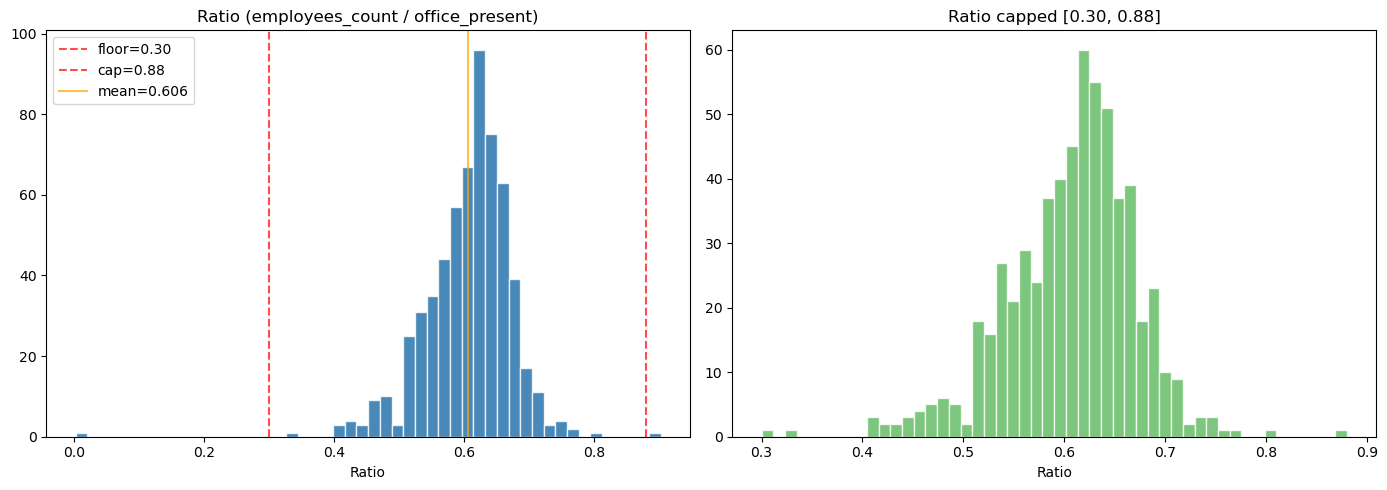

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_valid['ratio'], bins=50, color='#1b6ca8', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.30, color='red', ls='--', alpha=0.7, label='floor=0.30')
axes[0].axvline(x=0.88, color='red', ls='--', alpha=0.7, label='cap=0.88')
axes[0].axvline(x=df_valid['ratio'].mean(), color='orange', ls='-', alpha=0.7, label=f"mean={df_valid['ratio'].mean():.3f}")
axes[0].set_title('Ratio (employees_count / office_present)')
axes[0].set_xlabel('Ratio')
axes[0].legend()

axes[1].hist(df_valid['ratio_capped'], bins=50, color='#5cb85c', alpha=0.8, edgecolor='white')
axes[1].set_title('Ratio capped [0.30, 0.88]')
axes[1].set_xlabel('Ratio')

plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaning_ratio_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8 — Save Cleaned Data

Sauvegarde `data/processed/real_clean.csv` — point de départ pour tous les
notebooks下游 (02_feature_engineering, 03_training, etc.).

In [12]:
out_path = PROC_DIR / 'real_clean.csv'
df_valid.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"  Shape: {df_valid.shape}")
print(f"  Date range: {df_valid['Date'].min().date()} to {df_valid['Date'].max().date()}")
print(f"  Columns ({len(df_valid.columns)}): {list(df_valid.columns)}")
print(f"  Nulls: {df_valid.isnull().sum().sum()} (should be 0 except plat_principal_2)")
print()
print("Final column list:")
for i, c in enumerate(df_valid.columns, 1):
    nulls = df_valid[c].isnull().sum()
    null_str = f"  ({nulls} nulls)" if nulls > 0 else ""
    print(f"  {i:2d}. {c}{null_str}")

Saved: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\data\processed\real_clean.csv
  Shape: (605, 18)
  Date range: 2022-05-05 to 2024-12-31
  Columns (18): ['Date', 'office_present', 'employees_count', 'entrees', 'plat_principal_1', 'plat_principal_2', 'temperature', 'temperature_felt', 'precipitation_mm', 'precipitation_type', 'wind_gust_kmh', 'wind_speed_kmh', 'cloud_cover_pct', 'weather_conditions', 'dow', 'is_working_day', 'ratio', 'ratio_capped']
  Nulls: 226 (should be 0 except plat_principal_2)

Final column list:
   1. Date
   2. office_present
   3. employees_count
   4. entrees
   5. plat_principal_1
   6. plat_principal_2  (226 nulls)
   7. temperature
   8. temperature_felt
   9. precipitation_mm
  10. precipitation_type
  11. wind_gust_kmh
  12. wind_speed_kmh
  13. cloud_cover_pct
  14. weather_conditions
  15. dow
  16. is_working_day
  17. ratio
  18. ratio_capped


In [13]:
# -- Final summary ---------------------------------------------------------------
n_excluded = 666 - len(df_valid)
jan_feb_zero = df_raw[(df_raw['cantine_presence'] == 0) & (df_raw['Date'] < '2022-03-01')]
office_zero_total = df_raw[df_raw['office_presence'] == 0]
isolated_closures = df_raw[(df_raw['cantine_presence'] == 0) & (df_raw['Date'] >= '2022-03-01')]

print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Source: real.csv (666 rows, raw)")
print(f"Output: real_clean.csv ({len(df_valid)} rows, filtered)")
print(f"Date range: {df_valid['Date'].min().date()} to {df_valid['Date'].max().date()}")
print(f"Excluded: {n_excluded} rows")
print(f"  Jan-Feb 2022 (cantine closed): {len(jan_feb_zero)} rows")
print(f"  Feb-Mar 2022 (office=0): {len(office_zero_total)} rows")
print(f"  Isolated closures (post-Mar 2022): {len(isolated_closures)} rows")
print(f"Key stats:")
print(f"  office_present: mean={df_valid['office_present'].mean():.0f}, std={df_valid['office_present'].std():.0f}")
print(f"  employees_count: mean={df_valid['employees_count'].mean():.0f}, std={df_valid['employees_count'].std():.0f}")
print(f"  ratio: mean={df_valid['ratio'].mean():.3f}, std={df_valid['ratio'].std():.3f}")
print(f"  ratio_capped: [{df_valid['ratio_capped'].min():.2f}, {df_valid['ratio_capped'].max():.2f}]")
print(f"Weather nulls: filled (ffill+bfill) or already excluded")
print(f"Column names: cleaned, consistent with src/ codebase")
print("=" * 60)

DATA CLEANING SUMMARY
Source: real.csv (666 rows, raw)
Output: real_clean.csv (605 rows, filtered)
Date range: 2022-05-05 to 2024-12-31
Excluded: 61 rows
  Jan-Feb 2022 (cantine closed): 32 rows
  Feb-Mar 2022 (office=0): 37 rows
  Isolated closures (post-Mar 2022): 6 rows
Key stats:
  office_present: mean=545, std=57
  employees_count: mean=329, std=44
  ratio: mean=0.606, std=0.067
  ratio_capped: [0.30, 0.88]
Weather nulls: filled (ffill+bfill) or already excluded
Column names: cleaned, consistent with src/ codebase
